# Water-consumption (forelimb reaching) — NWB Data Access Demo

**Dataset:** Meletis Lab, Karolinska Institutet  
**Publication:** [Mantas et al. (2024) — bioRxiv](https://doi.org/10.1101/2024.12.22.629963)

This notebook demonstrates how to access each data stream in the water-consumption
(forelimb reaching-for-water) NWB files.

## About the experiment

Water-restricted mice in a 10 × 10 cm transparent-walled enclosure reach through a 1 cm
aperture to a pump-controlled waterspout located 1 cm beyond the wall. Sessions are 15 min
long and run on 4 consecutive days per mouse. Reach events are manually scored from a
60 fps lateral behavior video (FLIR camera); fiber photometry simultaneously records either
striatal dopamine release (dLight1.3b) or axonal calcium signals from SN dopamine neurons
projecting to the dorsal caudoputamen (jGCaMP8m).

- **Mice:** 25, across two mouse lines (`dat_cre`, `anxa1-flp`)
- **Sessions:** 59 total
- **Groups (from `details.csv.group`):**
  - `dLight_dStr` — dLight1.3b in dorsal caudoputamen (dCP; AP +0.74, ML ±1.5, DV −2.2)
  - `dLight_vStr` — dLight1.3b in central caudoputamen (cCP; AP +0.38, ML +2.0, DV −2.9)
  - `fp_dat` — jGCaMP8m axonal signals in dCP from pan-DA SN neurons (DAT-Cre)
  - `fp_anxa1` — jGCaMP8m axonal signals in dCP from Anxa1+ SN neurons (Anxa1-Flp)

> **Note on nomenclature:** `details.csv` uses `dLight_dStr` and `dLight_vStr` as raw lab
> codes. The lab confirmed these correspond to dCP and cCP respectively, consistent with
> the article nomenclature (same mapping as in the opto+dLight dataset).

## Data streams per NWB file

| Stream | NWB location | Rate | Description |
|--------|-------------|------|-------------|
| **Raw signal (470 nm)** | `acquisition/FiberPhotometrySeriesRawSignal` | ~60 Hz | Raw 470 nm fluorescence (dopamine-sensitive channel) |
| **Isosbestic reference (405 nm)** | `acquisition/FiberPhotometrySeriesIsosbesticControl` | ~60 Hz | Raw 405 nm fluorescence (motion/bleaching control) |
| **Fiber photometry dF/F** | `processing/ophys/FiberPhotometrySeriesDfOverF` | ~60 Hz | dF/F (470 nm − 405 nm isosbestic) |
| **Behavior video** | `acquisition/BehaviorVideo` | 60 fps | Lateral-view reaching video, stored by external reference (not copied) |
| **Reach annotations** | `processing/behavior/reaching_events` | — | Manually-scored reach events as an ndx-events `AnnotatedEventsTable` (one row per event type, ragged `event_times` + ragged per-event metadata columns including paw pixel coordinates `paw_x`/`paw_y`). |
| **FP metadata** | `general/lab_meta_data/fiber_photometry` | — | ndx-fiber-photometry: indicator, fiber, excitation sources |

## Setup

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from pynwb import read_nwb

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

## Load NWB file

Update the path below to point to your NWB file. This demo uses a full-session dLight recording
from the dorsal caudoputamen (group `dLight_dStr`).

In [17]:
nwb_path = "/Users/weian/catalystneuro/meletis-lab-to-nwb/nwb_output/water_consumption/sub-661507/sub-661507_ses-reaching-test-2023-06-20T12-22-30_behavior+image.nwb"

nwbfile = read_nwb(nwb_path)

print(f"Session ID:         {nwbfile.session_id}")
print(f"Session start:      {nwbfile.session_start_time}")
print(f"Session desc:       {nwbfile.session_description.strip()}...")
print("----")
print(f"Subject ID:         {nwbfile.subject.subject_id}")
print(f"Species:            {nwbfile.subject.species}")
print(f"Genotype:           {nwbfile.subject.genotype}")
print(f"Strain:             {nwbfile.subject.strain}")
print(f"Sex:                {nwbfile.subject.sex}")
print(f"Institution:        {nwbfile.institution}")
print(f"Lab:                {nwbfile.lab}")
print(f"Related pubs:       {nwbfile.related_publications}")

Session ID:         reaching-test-2023-06-20T12-22-30
Session start:      2023-06-20 12:22:30+02:00
Session desc:       Forelimb reaching-for-water session with simultaneous fiber photometry recording.
The per-session recording target (striatum vs SN) and indicator identity (dLight vs
GCaMP) are encoded in the `group` and `line` columns of details.csv....
----
Subject ID:         661507
Species:            Mus musculus
Genotype:           Dat_cre
Strain:             C57BL/6N
Sex:                M
Institution:        Karolinska Institutet
Lab:                Meletis
Related pubs:       ('doi:10.1101/2024.12.22.629963',)


## 1. Fiber photometry

Fiber photometry was acquired using the same Doric hardware and DoricStudio V5 pipeline as
the opto + dLight experiment. The NWB file exposes three traces:

- **`acquisition/FiberPhotometrySeriesRawSignal`** — raw 470 nm fluorescence (indicator channel)
- **`acquisition/FiberPhotometrySeriesIsosbesticControl`** — raw 405 nm isosbestic reference
- **`processing/ophys/FiberPhotometrySeriesDfOverF`** — isosbestic-corrected dF/F

Recording-location, indicator identity, and fiber device name depend on the session's `group`.
All groups use the same Doric 400 µm cannula (`optical_fiber_cpu`) implanted in the dCP or cCP.
For `fp_dat`/`fp_anxa1`, the virus is injected into the SNc but the **fiber is in the dCP**
to record axonal jGCaMP8m signals from the striatal projections of those SN neurons.

| Group | Location | Indicator | Fiber insertion |
|-------|----------|-----------|-----------------|
| `dLight_dStr` | Dorsal caudoputamen | dLight1.3b | dCP (AP +0.74, ML ±1.5, DV −2.2) |
| `dLight_vStr` | Central caudoputamen | dLight1.3b | cCP (AP +0.38, ML +2.0, DV −2.9) |
| `fp_dat` | Dorsal caudoputamen | jGCaMP8m | dCP (AP +0.74, ML ±1.5, DV −2.2) |
| `fp_anxa1` | Dorsal caudoputamen | jGCaMP8m | dCP (AP +0.74, ML ±1.5, DV −2.2) |

**Note:** Timestamps typically start at ~7–8 s due to the fiber photometry system warm-up.
Video and FP clocks are synchronized by Bonsai at session start — no additional alignment needed.

In [18]:
fp = nwbfile.processing["ophys"]["FiberPhotometrySeriesDfOverF"]
signal = fp.data[:]
timestamps = fp.timestamps[:]

print(f"Description:       {fp.description[:120]}...")
print(f"Unit:              {fp.unit}")
print(f"Data shape:        {signal.shape}")
print(f"Time range:        {timestamps[0]:.2f} – {timestamps[-1]:.2f} s")
print(f"Sampling rate:     ~{1 / np.median(np.diff(timestamps)):.1f} Hz")
print(f"Signal range:      {signal.min():.3f} to {signal.max():.3f} a.u.")

fp_meta = nwbfile.lab_meta_data["fiber_photometry"]
fp_table = fp_meta.fiber_photometry_table
print(f"\nRecording location:         {fp_table['location'][0]}")
print(f"Excitation wavelength:      {fp_table['excitation_wavelength_in_nm'][0]} nm")
print(f"Emission wavelength:        {fp_table['emission_wavelength_in_nm'][0]} nm")

ind = fp_table["indicator"][0]
print(f"\nIndicator label:            {ind.label}")
print(f"Indicator manufacturer:     {ind.manufacturer}")

# Optical fiber — retrieve directly from the FP table row
of_device = fp_table["optical_fiber"][0]
of_model = of_device.model
fi = of_device.fiber_insertion
print(f"\nOptical fiber device:       {of_device.name}  ({of_model.manufacturer}, {of_model.core_diameter_in_um:.0f} µm)")
if fi.insertion_position_ap_in_mm is not None:
    print(f"  implant AP:               {fi.insertion_position_ap_in_mm} mm")
    print(f"  implant ML:               {fi.insertion_position_ml_in_mm} mm")
    print(f"  implant DV:               {fi.insertion_position_dv_in_mm} mm")
    print(f"  hemisphere:               {fi.hemisphere}")

Description:       Isosbestic-corrected dF/F fiber photometry signal for indicator jGCaMP8m. Preprocessing in DoricStudio V5: raw 470 nm an...
Unit:              a.u.
Data shape:        (108770,)
Time range:        8.20 – 1821.02 s
Sampling rate:     ~60.0 Hz
Signal range:      -8.271 to 5.455 a.u.

Recording location:         Dorsal caudoputamen
Excitation wavelength:      470.0 nm
Emission wavelength:        525.0 nm

Indicator label:            jGCaMP8m
Indicator manufacturer:     Addgene

Optical fiber device:       optical_fiber_cpu  (Doric, 400 µm)
  implant AP:               0.74 mm
  implant ML:               1.5 mm
  implant DV:               -2.2 mm
  hemisphere:               right


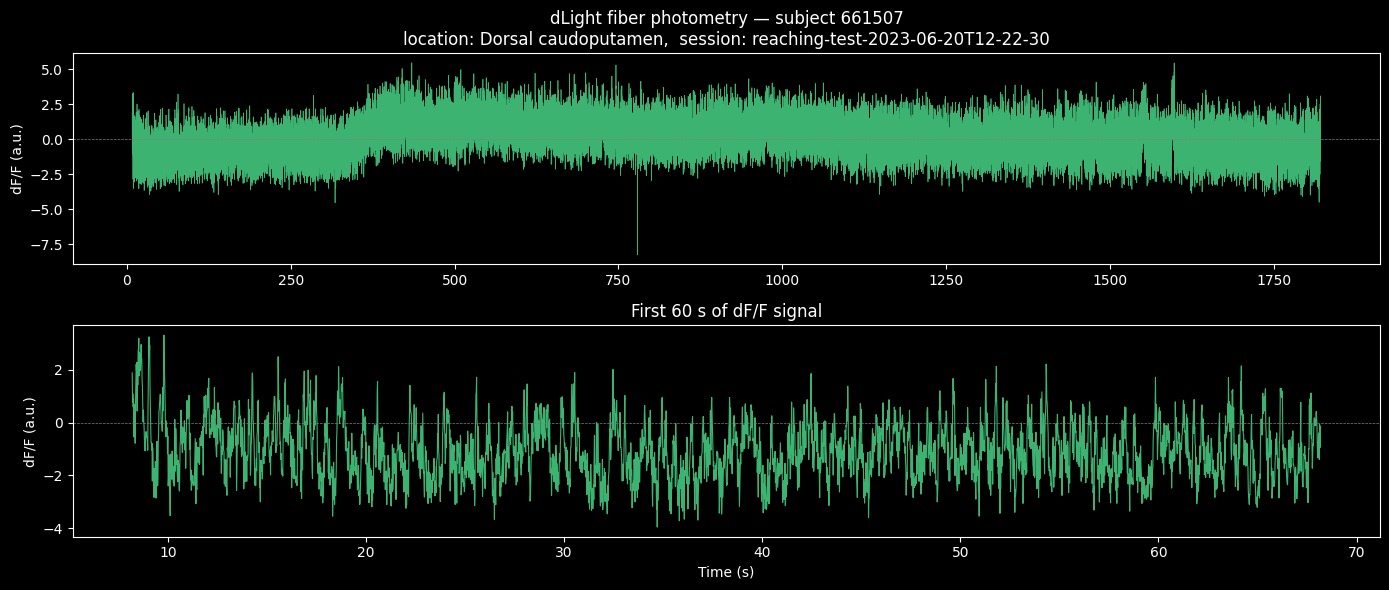

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(timestamps, signal, linewidth=0.5, color="mediumseagreen")
axes[0].set_ylabel("dF/F (a.u.)")
axes[0].set_title(
    f"dLight fiber photometry — subject {nwbfile.subject.subject_id}\n"
    f"location: {fp_table['location'][0]},  session: {nwbfile.session_id}"
)
axes[0].axhline(0, color="gray", linewidth=0.5, linestyle="--")

t_end = min(timestamps[0] + 60, timestamps[-1])
mask = timestamps <= t_end
axes[1].plot(timestamps[mask], signal[mask], linewidth=0.8, color="mediumseagreen")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("dF/F (a.u.)")
axes[1].set_title("First 60 s of dF/F signal")
axes[1].axhline(0, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()

### Raw acquisition traces

The raw 470 nm and 405 nm fluorescence traces output by DoricStudio V5 are stored in
`acquisition/` with matching timestamps, so the dF/F can be re-derived downstream if needed.

Signal (470 nm):    (108807,),  range [296.970, 474.967] a.u.
Reference (405 nm): (108807,),  range [335.652, 532.739] a.u.
Time range:         8.18 – 1821.62 s
Sampling rate:      ~60.0 Hz


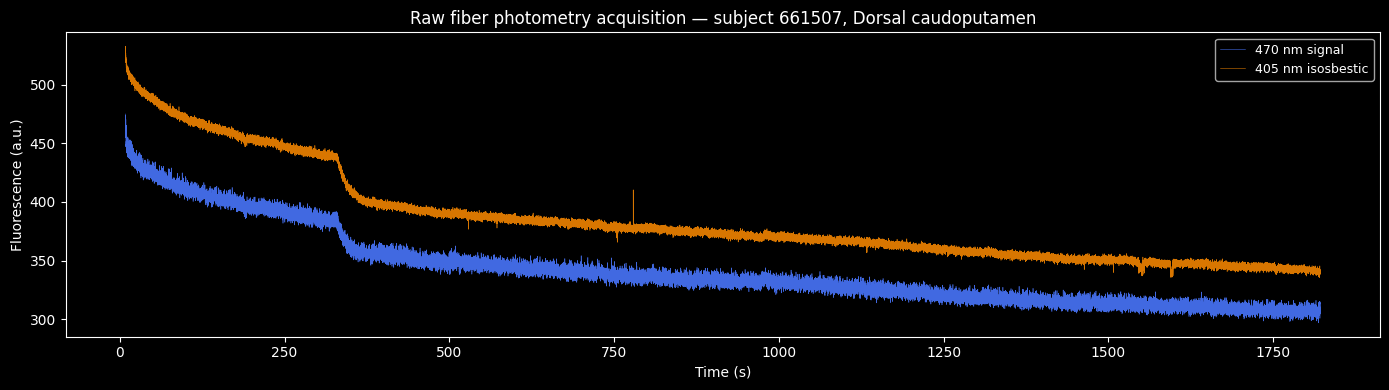

In [20]:
raw_sig = nwbfile.acquisition["FiberPhotometrySeriesRawSignal"]
raw_ref = nwbfile.acquisition["FiberPhotometrySeriesIsosbesticControl"]

sig_data = raw_sig.data[:]
ref_data = raw_ref.data[:]

if raw_sig.timestamps is not None:
    raw_time = raw_sig.timestamps[:]
else:
    raw_time = raw_sig.starting_time + np.arange(len(sig_data)) / raw_sig.rate

print(f"Signal (470 nm):    {sig_data.shape},  range [{sig_data.min():.3f}, {sig_data.max():.3f}] a.u.")
print(f"Reference (405 nm): {ref_data.shape},  range [{ref_data.min():.3f}, {ref_data.max():.3f}] a.u.")
print(f"Time range:         {raw_time[0]:.2f} – {raw_time[-1]:.2f} s")
print(f"Sampling rate:      ~{1 / np.median(np.diff(raw_time)):.1f} Hz")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(raw_time, sig_data, linewidth=0.4, color="royalblue", label="470 nm signal")
ax.plot(raw_time, ref_data, linewidth=0.4, color="darkorange", alpha=0.85, label="405 nm isosbestic")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Fluorescence (a.u.)")
ax.set_title(
    f"Raw fiber photometry acquisition — subject {nwbfile.subject.subject_id}, "
    f"{fp_table['location'][0]}"
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 2. Reach annotations

Manually-scored reach events live at `processing/behavior/reaching_events` as an
ndx-events `AnnotatedEventsTable`. Each **row** of that table is one event **type**
(`correct`, `miss`, `empty`, `drop`, `semidrop`, or `unknown`); each row carries a
ragged `event_times` column plus ragged per-event metadata columns. Event times are in
seconds relative to `session_start_time` (computed as `frame_index / 60 Hz`).

| Column | Meaning |
|--------|---------|
| `label` | Event type (row identifier). |
| `event_description` | Human-readable description of the event type. |
| `event_times` | Ragged list of onset times (seconds from session start) for all events of this type. |
| `paw` | Body part contacting the spout for each event: `mouth`, `right`, `left`, or `unknown`. |
| `frame` | Annotated video frame index (0-based) for each event. |
| `target_x`, `target_y` | Spout position in video pixels, per event (rich annotations only). |
| `paw_x`, `paw_y` | Paw pixel coordinates at each event; origin top-left, x right, y down (rich annotations only). |
| `reference_px` | Pixel reference distance used for cm conversion, per event. |
| `distance_px`, `distance_cm` | Reach distance to spout in pixels / cm, per event. |

Many sessions use a minimal schema (`frame`, `paw`, `event_type` only); for those, the
coordinate and distance columns are `NaN`. The cell below flattens the ragged
`AnnotatedEventsTable` into a long one-row-per-event DataFrame (`df`) for convenience
in downstream plots.

In [21]:
import pandas as pd


def _flatten_reaching_events(events_table) -> pd.DataFrame:
    """Flatten an AnnotatedEventsTable into a long one-row-per-event DataFrame."""
    df_types = events_table.to_dataframe()
    metadata_cols = [
        c for c in df_types.columns
        if c not in ("event_times", "label", "event_description")
    ]
    records = []
    for _, row in df_types.iterrows():
        event_times = list(row["event_times"])
        for i in range(len(event_times)):
            rec = {"event_type": row["label"], "event_time": float(event_times[i])}
            for col in metadata_cols:
                rec[col] = row[col][i]
            records.append(rec)
    out = pd.DataFrame.from_records(records)
    if len(out):
        out = out.sort_values("event_time").reset_index(drop=True)
    return out


if "behavior" not in nwbfile.processing:
    print(
        "No 'behavior' processing module found in this file.\n"
        "Re-run the conversion to generate an up-to-date NWB file, then re-execute this cell.\n"
        "Skipping reach-annotation cells."
    )
    df = pd.DataFrame()
else:
    reach = nwbfile.processing["behavior"]["reaching_events"]
    df = _flatten_reaching_events(reach)

    print(f"AnnotatedEventsTable event types: {list(reach['label'][:])}")
    print(f"Total reach events: {len(df)}")
    print(f"Event type counts: {df['event_type'].value_counts().to_dict()}")
    print(f"Paw counts:        {df['paw'].value_counts().to_dict()}")
    print()
    print("First 5 events:")
    display(df.head())

AnnotatedEventsTable event types: ['correct']
Total reach events: 16
Event type counts: {'correct': 16}
Paw counts:        {'mouth': 16}

First 5 events:


,event_type,event_time,frame,paw,target_x,target_y,paw_x,paw_y,reference_px,distance_px,distance_cm
0,correct,117.133333,7028,mouth,69.85,-97.25,88.12,-143.46,370.75,49.689125,0.134025
1,correct,158.083333,9485,mouth,69.85,-97.25,104.24,-67.16,370.75,45.693753,0.123248
2,correct,309.866667,18592,mouth,69.85,-97.25,108.54,-158.51,370.75,72.447708,0.195410
3,correct,316.566667,18994,mouth,69.85,-97.25,102.09,-155.28,370.75,66.383772,0.179054
4,correct,510.700000,30642,mouth,69.85,-97.25,94.57,-168.18,370.75,75.108640,0.202588


### Reach event raster

One subplot per event type (e.g. `correct`, `miss`, `empty`, `drop`), each showing when
that event type occurred across the session as tick marks on a shared time axis. Subplots
share both x and y axes so the temporal density is directly comparable across outcome types.

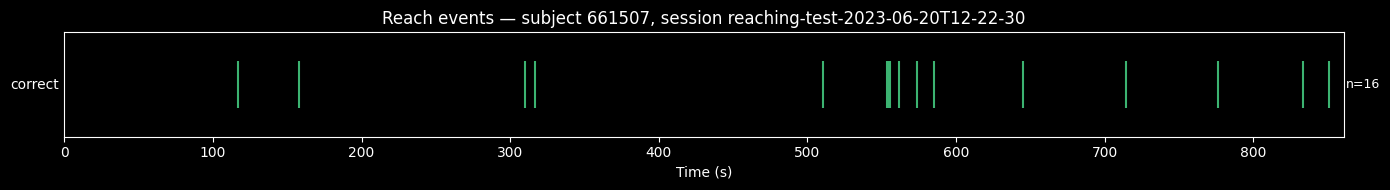

In [22]:
if len(df) > 0:
    palette = {"correct": "mediumseagreen", "miss": "steelblue", "empty": "slategray",
               "drop": "indianred", "semidrop": "orange", "unknown": "black"}
    event_types = list(reach["label"][:])
    n_types = len(event_types)

    fig, axes = plt.subplots(
        n_types, 1,
        figsize=(14, max(2.0, 1.6 * n_types)),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    t_max = df["event_time"].max()

    for i, event_type in enumerate(event_types):
        ax = axes[i, 0]
        sub = df[df["event_type"] == event_type]
        times = sub["event_time"].values
        color = palette.get(event_type, "black")
        ax.eventplot(times, orientation="horizontal", colors=color, linewidths=1.5, linelengths=0.6)
        ax.set_ylabel(event_type, rotation=0, ha="right", va="center", fontsize=10)
        ax.set_yticks([])
        ax.annotate(
            f"n={len(times)}",
            xy=(1.002, 0.5), xycoords="axes fraction",
            ha="left", va="center", fontsize=9,
        )
        ax.set_xlim(0, t_max + 10)

    axes[-1, 0].set_xlabel("Time (s)")
    axes[0, 0].set_title(
        f"Reach events — subject {nwbfile.subject.subject_id}, session {nwbfile.session_id}"
    )
    fig.tight_layout()
    plt.show()
else:
    print("No reach events found in this file.")

## 3. dF/F aligned to reach events

Peri-event windowing of the dF/F signal around each reach onset. Separate traces per
outcome let you compare dopamine dynamics across `correct`, `miss`, `empty`, and `drop`
events.

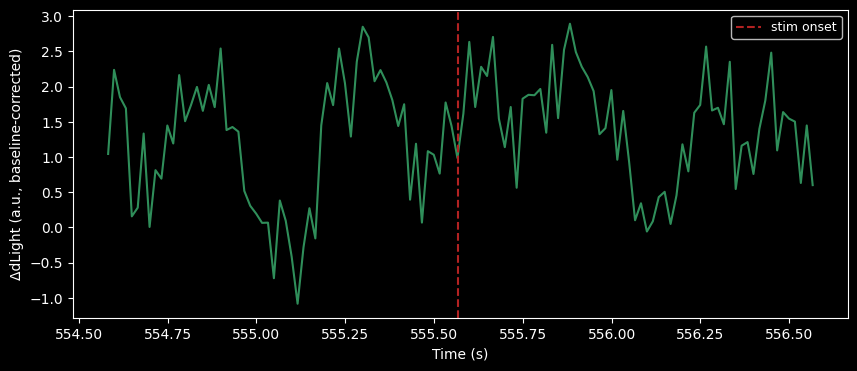

In [23]:
fp_signal = nwbfile.processing["ophys"]["FiberPhotometrySeriesDfOverF"].data[:]
fp_time = nwbfile.processing["ophys"]["FiberPhotometrySeriesDfOverF"].timestamps[:]

stim_onset = df.iloc[7]["event_time"]
pre_s = 1.0
post_s = 1.0

mask = (fp_time >= stim_onset - pre_s) & (fp_time < stim_onset + post_s)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fp_time[mask], fp_signal[mask], color="mediumseagreen", alpha=0.8, linewidth=1.5)
ax.axvline(stim_onset, color="firebrick", linestyle="--", linewidth=1.5, label="stim onset")

ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
ax.set_xlabel("Time (s)")
ax.set_ylabel("ΔdLight (a.u., baseline-corrected)")
plt.show()

In [24]:
df

,event_type,event_time,frame,paw,target_x,target_y,paw_x,paw_y,reference_px,distance_px,distance_cm
0,correct,117.133333,7028,mouth,69.85,-97.25,88.12,-143.46,370.75,49.689125,0.134025
1,correct,158.083333,9485,mouth,69.85,-97.25,104.24,-67.16,370.75,45.693753,0.123248
2,correct,309.866667,18592,mouth,69.85,-97.25,108.54,-158.51,370.75,72.447708,0.195410
3,correct,316.566667,18994,mouth,69.85,-97.25,102.09,-155.28,370.75,66.383772,0.179054
4,correct,510.700000,30642,mouth,69.85,-97.25,94.57,-168.18,370.75,75.108640,0.202588
5,correct,553.800000,33228,mouth,69.85,-97.25,85.97,-164.96,370.75,69.594012,0.187713
6,correct,554.366667,33262,mouth,69.85,-97.25,94.57,-157.43,370.75,65.057077,0.175476
7,correct,555.566667,33334,mouth,69.85,-97.25,77.37,-161.73,370.75,64.914924,0.175093
8,correct,561.833333,33710,mouth,69.85,-97.25,80.60,-138.09,370.75,42.226133,0.113895
9,correct,573.416667,34405,mouth,69.85,-97.25,85.97,-186.45,370.75,90.638908,0.244477


{'correct': 16}


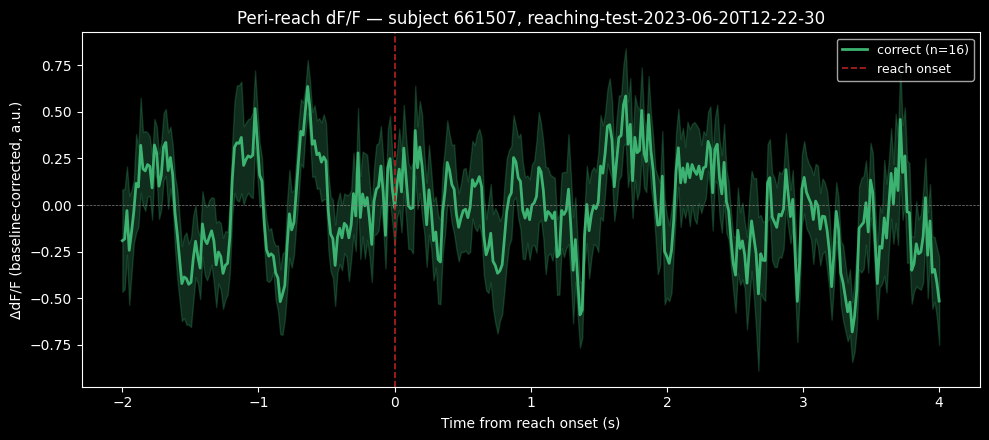

In [25]:
pre_s = 2.0
post_s = 4.0

fp_sig = nwbfile.processing["ophys"]["FiberPhotometrySeriesDfOverF"].data[:]
fp_time = nwbfile.processing["ophys"]["FiberPhotometrySeriesDfOverF"].timestamps[:]

dt = np.median(np.diff(fp_time))
fs = 1.0 / dt
n_pre = int(pre_s * fs)
n_post = int(post_s * fs)
n_samples = n_pre + n_post
t_axis = np.linspace(-pre_s, post_s, n_samples)

outcome_trials: dict[str, list[np.ndarray]] = {}
for _, row in df.iterrows():
    onset = row["event_time"]
    if onset - pre_s < fp_time[0] or onset + post_s > fp_time[-1]:
        continue
    t_start = onset - pre_s
    t_end = onset + post_s
    mask = (fp_time >= t_start) & (fp_time < t_end)
    if mask.sum() < n_samples * 0.9:
        continue
    t_grid = np.linspace(t_start, t_end, n_samples)
    snippet = np.interp(t_grid, fp_time[mask], fp_sig[mask])
    snippet -= snippet[:n_pre].mean()  # baseline-correct to pre-event mean
    outcome_trials.setdefault(row["event_type"], []).append(snippet)

print({k: len(v) for k, v in outcome_trials.items()})

fig, ax = plt.subplots(figsize=(10, 4.5))
palette = {"correct": "mediumseagreen", "miss": "steelblue", "empty": "slategray",
           "drop": "indianred", "semidrop": "orange", "unknown": "black"}
for outcome, trials in outcome_trials.items():
    arr = np.array(trials)
    mean_trace = arr.mean(axis=0)
    sem_trace = arr.std(axis=0) / np.sqrt(len(arr))
    color = palette.get(outcome, "black")
    ax.plot(t_axis, mean_trace, linewidth=2, color=color, label=f"{outcome} (n={len(arr)})")
    ax.fill_between(t_axis, mean_trace - sem_trace, mean_trace + sem_trace, color=color, alpha=0.25)
ax.axvline(0, color="firebrick", linestyle="--", linewidth=1.2, label="reach onset")
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.set_xlabel("Time from reach onset (s)")
ax.set_ylabel("ΔdF/F (baseline-corrected, a.u.)")
ax.set_title(f"Peri-reach dF/F — subject {nwbfile.subject.subject_id}, {nwbfile.session_id}")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

## 4. Reach events on top of the dF/F trace

A zoomed-in window showing the dF/F trace annotated with reach markers colored by outcome.

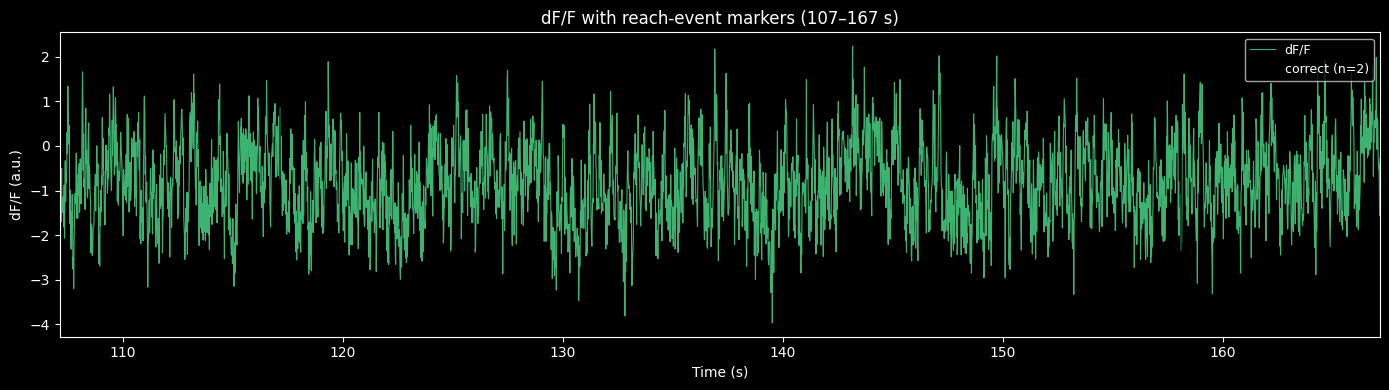

In [26]:
# Find a 60-second window with several reach events
if len(df) > 0:
    first_event = df["event_time"].iloc[0]
    t0 = max(timestamps[0], first_event - 10.0)
    t1 = t0 + 60.0
else:
    t0, t1 = timestamps[0], timestamps[0] + 60.0

mask = (timestamps >= t0) & (timestamps <= t1)
events_window = df[(df["event_time"] >= t0) & (df["event_time"] <= t1)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(timestamps[mask], signal[mask], linewidth=0.8, color="mediumseagreen", label="dF/F")
for outcome, color in palette.items():
    sub = events_window[events_window["event_type"] == outcome]
    if len(sub):
        ax.vlines(sub["event_time"], signal[mask].min(), signal[mask].max(),
                  color="black", alpha=0.7, linewidth=1.2, label=f"{outcome} (n={len(sub)})")
ax.set_xlim(t0, t1)
ax.set_xlabel("Time (s)")
ax.set_ylabel("dF/F (a.u.)")
ax.set_title(f"dF/F with reach-event markers ({t0:.0f}–{t1:.0f} s)")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

## 5. Behavior video (external reference)

The lateral behavior video is stored by external reference, not copied into the NWB file.
The `BehaviorVideo` object in `acquisition/` carries the path(s) to the original `.avi`.

In [27]:
from pynwb.image import ImageSeries

video_keys = [k for k, v in nwbfile.acquisition.items() if isinstance(v, ImageSeries)]
bv = nwbfile.acquisition[video_keys[0]]
print(f"Video name:        {bv.name}")
print(f"Description:       {bv.description[:120] if bv.description else ''}")
print(f"External files:    {list(bv.external_file[:])}")

Video name:        Video reaching_test_2023-06-20T12_22_30
Description:       Video recorded by camera.
External files:    ['/Volumes/T9/data/Meletis/water_consumption/videos/reaching_test_2023-06-20T12_22_30.avi']


## 6. NWB file structure overview

In [28]:
print("=== Acquisition ===")
for name, obj in nwbfile.acquisition.items():
    print(f"  {name}: {type(obj).__name__}")

print("\n=== Processing ===")
for mod_name, mod in nwbfile.processing.items():
    print(f"  {mod_name}: {mod.description}")
    for name, obj in mod.data_interfaces.items():
        extra = ""
        if type(obj).__name__ == "AnnotatedEventsTable":
            n_types = len(obj)
            n_events = sum(len(obj["event_times"][i]) for i in range(n_types))
            extra = f" ({n_types} event types, {n_events} events)"
        print(f"    {name}: {type(obj).__name__}{extra}")

if len(nwbfile.intervals):
    print("\n=== Intervals ===")
    for name, obj in nwbfile.intervals.items():
        df_iv = obj.to_dataframe()
        print(f"  {name}: {type(obj).__name__} ({len(df_iv)} rows)")

print("\n=== Lab metadata ===")
for name, obj in nwbfile.lab_meta_data.items():
    print(f"  {name}: {type(obj).__name__}")

print("\n=== Devices ===")
for name, obj in nwbfile.devices.items():
    print(f"  {name}: {type(obj).__name__}")

print("\n=== Subject ===")
s = nwbfile.subject
print(f"  subject_id: {s.subject_id}")
print(f"  species:    {s.species}")
print(f"  genotype:   {s.genotype}")
print(f"  strain:     {s.strain}")
print(f"  sex:        {s.sex}")

=== Acquisition ===
  FiberPhotometrySeriesIsosbesticControl: FiberPhotometryResponseSeries
  FiberPhotometrySeriesRawSignal: FiberPhotometryResponseSeries
  Video reaching_test_2023-06-20T12_22_30: ImageSeries

=== Processing ===
  behavior: processed behavioral data
    reaching_events: AnnotatedEventsTable (1 event types, 16 events)
  ophys: Processed optical physiology data. Contains isosbestic-corrected dF/F fluorescence signals from the reaching task for water reward fiber photometry recordings.
    FiberPhotometrySeriesDfOverF: FiberPhotometryResponseSeries

=== Lab metadata ===
  fiber_photometry: FiberPhotometry

=== Devices ===
  FLIR Camera: Device
  excitation_source_isosbestic: ExcitationSource
  excitation_source_signal: ExcitationSource
  optical_fiber_cpu: OpticalFiber
  photodetector: Photodetector

=== Subject ===
  subject_id: 661507
  species:    Mus musculus
  genotype:   Dat_cre
  strain:     C57BL/6N
  sex:        M


In [29]:
nwbfile.read_io.close()